# Mandarin Tone Classifier

Classifies isolated Mandarin syllables into tones 1–4 using mel spectrograms and a CNN.

- **Dataset**: Tone Perfect — ~10,000 studio-recorded MP3s, balanced across 4 tones
- **Features**: 128×128 mel spectrograms (librosa)
- **Model**: 4-layer CNN (PyTorch)
- **Result**: 100% test accuracy

## 1. Setup

In [1]:
!pip install librosa torch scikit-learn seaborn

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
import os, re, random
import numpy as np
import librosa
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter

DATA_DIR = '/content/drive/MyDrive/mandarin-tone-classification/tone_perfect/'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


## 2. Exploring the Data

Visualize raw waveforms and mel spectrograms for all 4 tones.

We can already see the tones in just their waveforms. However, that is not enough for the CNN to notice.

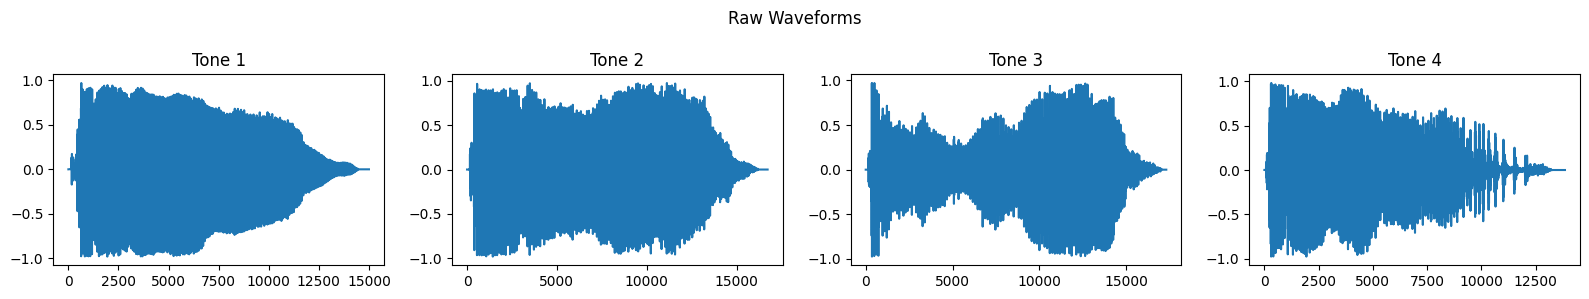

In [18]:
samples = {}
for tone in range(1, 5):
    samples[tone], _ = librosa.load(DATA_DIR + f'a{tone}_FV1_MP3.mp3', sr=22050)

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for i, tone in enumerate(range(1, 5)):
    axes[i].plot(samples[tone])
    axes[i].set_title(f'Tone {tone}')
plt.suptitle('Raw Waveforms')
plt.tight_layout()
plt.show()

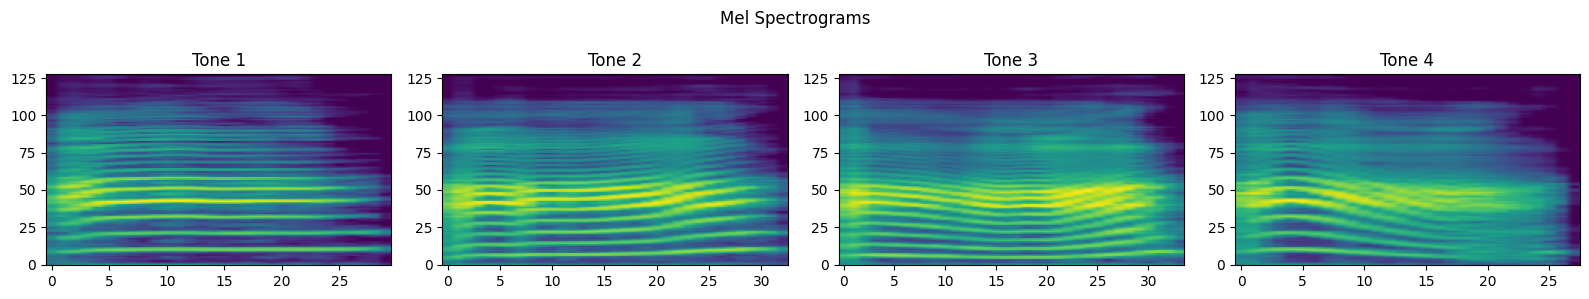

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for i, tone in enumerate(range(1, 5)):
    mel = librosa.feature.melspectrogram(y=samples[tone], sr=22050, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    axes[i].imshow(mel_db, aspect='auto', origin='lower')
    axes[i].set_title(f'Tone {tone}')
plt.suptitle('Mel Spectrograms')
plt.tight_layout()
plt.show()

## 3. Data Preparation

Parse tone labels from filenames, extract mel spectrograms, split into train/val/test.

In [20]:
names = os.listdir(DATA_DIR)
tones = []
for name in names:
    match = re.match(r'[a-z]+([1-4])_', name)
    if match:
        tones.append((DATA_DIR + name, int(match.group(1)) - 1))

print(f'Total: {len(tones)}') # my total is a bit different because of google drive
print(Counter(label for _, label in tones))

Total: 9956
Counter({2: 2490, 3: 2490, 0: 2489, 1: 2487})


In [21]:
def to_melspectrogram(path):
    y, _ = librosa.load(path, sr=22050)
    mel = librosa.feature.melspectrogram(y=y, sr=22050, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    if mel_db.shape[1] < 64:
        mel_db = np.pad(mel_db, ((0, 0), (0, 64 - mel_db.shape[1])))
    else:
        mel_db = mel_db[:, :64]
    mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-8)
    return mel_db.astype(np.float32)


print('Precomputing spectrograms...')
precomputed = []
for i, (path, label) in enumerate(tones):
    precomputed.append((to_melspectrogram(path), label))
    if (i + 1) % 2000 == 0:
        print(f'  {i+1}/{len(tones)}')
print('Done.')

Precomputing spectrograms...
  2000/9956
  4000/9956
  6000/9956
  8000/9956
Done.


In [22]:
class ToneDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        mel, label = self.samples[idx]
        return torch.tensor(mel).unsqueeze(0), torch.tensor(label, dtype=torch.long)


random.seed(13) # favorite number
random.shuffle(precomputed)

idx1, idx2 = int(len(precomputed) * 0.8), int(len(precomputed) * 0.9)
train_loader = DataLoader(ToneDataset(precomputed[:idx1]),     batch_size=64, shuffle=True,  num_workers=2)
val_loader   = DataLoader(ToneDataset(precomputed[idx1:idx2]), batch_size=64, shuffle=False, num_workers=2)
test_loader  = DataLoader(ToneDataset(precomputed[idx2:]),     batch_size=64, shuffle=False, num_workers=2)

print(f'Train: {idx1} | Val: {idx2-idx1} | Test: {len(precomputed)-idx2}')

Train: 7964 | Val: 996 | Test: 996


## 4. Data Augmentation

SpecAugment masks random time and frequency strips on the spectrogram during training, forcing the model to be robust to noise and distortion.

In [24]:
def spec_augment(mel, num_time_masks=2, num_freq_masks=2, time_width=10, freq_width=20, noise_std=0.05):
    mel = mel.copy()
    _, F, T = mel.shape  # (1, 128, 64)
    # Mask random time strips
    for _ in range(num_time_masks):
        t = random.randint(0, T - time_width)
        mel[:, :, t:t + time_width] = 0
    # Mask random frequency strips
    for _ in range(num_freq_masks):
        f = random.randint(0, F - freq_width)
        mel[:, f:f + freq_width, :] = 0
    # Add Gaussian noise to simulate background noise
    mel += np.random.normal(0, noise_std, mel.shape).astype(np.float32)
    return mel


class ToneDataset(Dataset):
    def __init__(self, samples, augment=False):
        self.samples = samples
        self.augment = augment

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        mel, label = self.samples[idx]
        x = torch.tensor(mel).unsqueeze(0)  # (1, 128, 64)
        if self.augment:
            x = torch.tensor(spec_augment(x.numpy()))
        return x, torch.tensor(label, dtype=torch.long)


# Rebuild loaders — augment=True only for training
train_loader = DataLoader(ToneDataset(precomputed[:idx1], augment=True),  batch_size=64, shuffle=True,  num_workers=2)
val_loader   = DataLoader(ToneDataset(precomputed[idx1:idx2]),             batch_size=64, shuffle=False, num_workers=2)
test_loader  = DataLoader(ToneDataset(precomputed[idx2:]),                 batch_size=64, shuffle=False, num_workers=2)

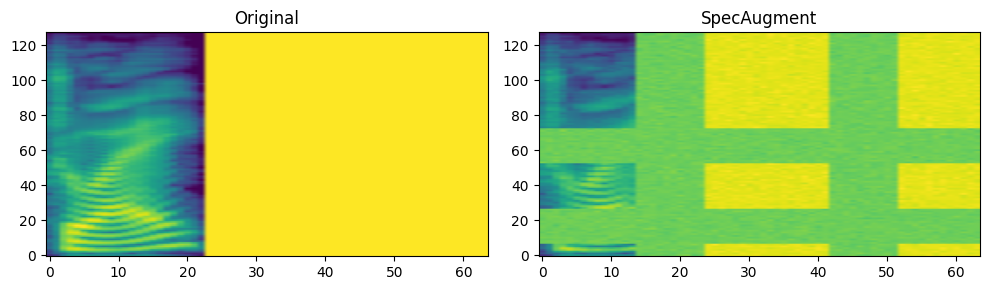

In [29]:
# Visualize original vs augmented spectrogram
mel_orig, _ = precomputed[0]
mel_aug = spec_augment(mel_orig[np.newaxis])[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
ax1.imshow(mel_orig, aspect='auto', origin='lower'); ax1.set_title('Original')
ax2.imshow(mel_aug,  aspect='auto', origin='lower'); ax2.set_title('SpecAugment')
plt.tight_layout()
plt.show()

## 5. Model

4-block CNN: Conv2d → BatchNorm → ReLU → Pool, followed by a 2-layer classifier.

In [30]:
class ToneCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 4),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = ToneCNN().to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Parameters: 422,212


## 6. Training

In [31]:
EPOCHS = 10
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss, correct, total = 0.0, 0, 0
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += x.size(0)
    train_loss /= total
    train_acc = correct / total

    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            val_loss += criterion(out, y).item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)
    val_loss /= total
    val_acc = correct / total
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pt')

    print(f'Epoch {epoch:02d} | train loss {train_loss:.4f} acc {train_acc:.3f} | val loss {val_loss:.4f} acc {val_acc:.3f}')

print(f'Best val acc: {best_val_acc:.3f}')

Epoch 01 | train loss 0.6947 acc 0.719 | val loss 0.1288 acc 0.945
Epoch 02 | train loss 0.2927 acc 0.894 | val loss 0.5686 acc 0.843
Epoch 03 | train loss 0.2268 acc 0.920 | val loss 0.0516 acc 0.975
Epoch 04 | train loss 0.1701 acc 0.937 | val loss 0.0287 acc 0.987
Epoch 05 | train loss 0.1397 acc 0.954 | val loss 0.0195 acc 0.995
Epoch 06 | train loss 0.1163 acc 0.959 | val loss 0.0185 acc 0.991
Epoch 07 | train loss 0.1080 acc 0.964 | val loss 0.0345 acc 0.983
Epoch 08 | train loss 0.0905 acc 0.970 | val loss 0.0028 acc 0.998
Epoch 09 | train loss 0.0793 acc 0.975 | val loss 0.0007 acc 1.000
Epoch 10 | train loss 0.0739 acc 0.976 | val loss 0.0015 acc 1.000
Best val acc: 1.000


## 7. Evaluation

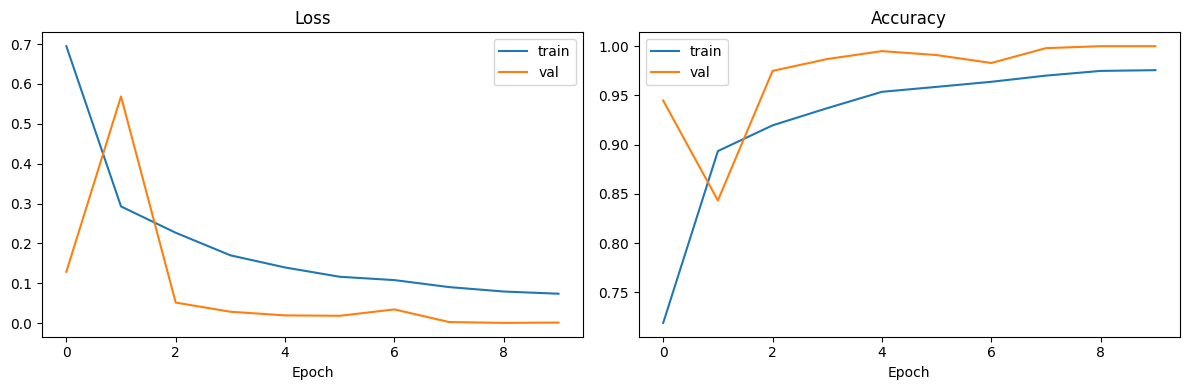

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['train_loss'], label='train')
ax1.plot(history['val_loss'],   label='val')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()
ax2.plot(history['train_acc'], label='train')
ax2.plot(history['val_acc'],   label='val')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

      Tone 1       1.00      1.00      1.00       265
      Tone 2       1.00      0.99      0.99       250
      Tone 3       0.99      0.99      0.99       243
      Tone 4       1.00      1.00      1.00       238

    accuracy                           0.99       996
   macro avg       0.99      0.99      0.99       996
weighted avg       0.99      0.99      0.99       996



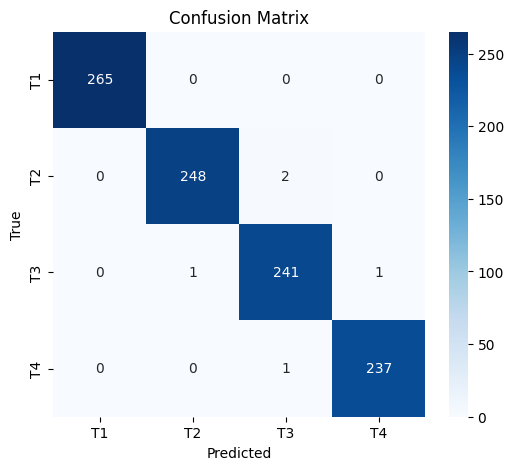

In [33]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.load_state_dict(torch.load('best_model.pt', map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        preds = model(x.to(DEVICE)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())

print(classification_report(all_labels, all_preds, target_names=['Tone 1', 'Tone 2', 'Tone 3', 'Tone 4']))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['T1','T2','T3','T4'], yticklabels=['T1','T2','T3','T4'])
plt.ylabel('True'); plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()